In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("final_heart_disease_uci.csv")
df

,age,sex,trestbps,chol,thalch,exang,oldpeak,ca,cp_atypical angina,cp_non-anginal,thal_normal,target
0,63,1,145.0,233.0,150.0,0,2.3,0.0,0,0,0,0
1,67,1,160.0,286.0,108.0,1,1.5,3.0,0,0,1,1
2,67,1,120.0,229.0,129.0,1,2.6,2.0,0,0,0,1
3,37,1,130.0,250.0,187.0,0,3.5,0.0,0,1,1,0
4,41,0,130.0,204.0,172.0,0,1.4,0.0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
915,54,0,127.0,333.0,154.0,0,0.0,0.0,0,0,1,1
916,62,1,130.0,139.0,140.0,0,0.5,0.0,0,0,1,0
917,55,1,122.0,223.0,100.0,0,0.0,0.0,0,0,0,1
918,58,1,130.0,385.0,140.0,0,0.5,0.0,0,0,1,0


In [2]:
X = df.iloc[: , :11]

In [3]:
X

,age,sex,trestbps,chol,thalch,exang,oldpeak,ca,cp_atypical angina,cp_non-anginal,thal_normal
0,63,1,145.0,233.0,150.0,0,2.3,0.0,0,0,0
1,67,1,160.0,286.0,108.0,1,1.5,3.0,0,0,1
2,67,1,120.0,229.0,129.0,1,2.6,2.0,0,0,0
3,37,1,130.0,250.0,187.0,0,3.5,0.0,0,1,1
4,41,0,130.0,204.0,172.0,0,1.4,0.0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...
915,54,0,127.0,333.0,154.0,0,0.0,0.0,0,0,1
916,62,1,130.0,139.0,140.0,0,0.5,0.0,0,0,1
917,55,1,122.0,223.0,100.0,0,0.0,0.0,0,0,0
918,58,1,130.0,385.0,140.0,0,0.5,0.0,0,0,1


In [4]:
Y = df["target"]

In [5]:
Y

0      0
1      1
2      1
3      0
4      0
      ..
915    1
916    0
917    1
918    0
919    1
Name: target, Length: 920, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test  = train_test_split(X, Y , test_size= 0.2 , random_state=42)

In [7]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(min_samples_split = 2 , min_samples_leaf  = 5, 
                            n_estimators = 80 , max_samples = 0.75 , random_state= 42 , max_depth = 8 , bootstrap = True, oob_score = True)
rf.fit(X_train , y_train)
y_pred = rf.predict(X_test)
y_pred

array([0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1])

In [8]:
from sklearn.metrics import confusion_matrix , accuracy_score
cm = confusion_matrix(y_test , y_pred)
cm

array([[65, 10],
       [11, 98]])

In [9]:
accuracy_score(y_test , y_pred)

0.8858695652173914

In [10]:
import pickle



heart_features = list(X_train.columns)

# save
with open("heart_model.pkl", "wb") as f:
    pickle.dump(rf, f)

with open("heart_features.pkl", "wb") as f:
    pickle.dump(heart_features, f)

In [57]:
probs = rf.predict_proba(X_test)
probs

array([[0.88671942, 0.11328058],
       [0.47924636, 0.52075364],
       [0.07567821, 0.92432179],
       [0.30070019, 0.69929981],
       [0.0605279 , 0.9394721 ],
       [0.26875621, 0.73124379],
       [0.88671942, 0.11328058],
       [0.05097348, 0.94902652],
       [0.15830591, 0.84169409],
       [0.44497228, 0.55502772],
       [0.77131058, 0.22868942],
       [0.19053682, 0.80946318],
       [0.05097348, 0.94902652],
       [0.72634417, 0.27365583],
       [0.26856568, 0.73143432],
       [0.66665905, 0.33334095],
       [0.86900499, 0.13099501],
       [0.73075186, 0.26924814],
       [0.41048703, 0.58951297],
       [0.05981674, 0.94018326],
       [0.72634417, 0.27365583],
       [0.35215727, 0.64784273],
       [0.09465563, 0.90534437],
       [0.40092018, 0.59907982],
       [0.55821464, 0.44178536],
       [0.18693664, 0.81306336],
       [0.45433066, 0.54566934],
       [0.73075186, 0.26924814],
       [0.39284336, 0.60715664],
       [0.74438761, 0.25561239],
       [0.

In [34]:
risk_prob = probs[:,1]
risk_prob

array([0.06230826, 0.10293979, 0.90778886, 0.81383558, 0.60325286,
       0.36272215, 0.18848927, 0.93711408, 0.81842823, 0.52640816,
       0.64604287, 0.90786966, 0.69981537, 0.66837715, 0.71752272,
       0.21883493, 0.07752496, 0.33634248, 0.76000764, 0.81414162,
       0.10882557, 0.44563016, 0.97088695, 0.81840533, 0.7370234 ,
       0.91555684, 0.9221185 , 0.05016985, 0.64557214, 0.24670166,
       0.27762577, 0.53189796, 0.10784804, 0.70577023, 0.03710251,
       0.6376847 , 0.37674114, 0.40996824, 0.63052921, 0.5110996 ,
       0.90343358, 0.32849242, 0.81996084, 0.28278999, 0.55095506,
       0.58270111, 0.96167671, 0.64525827, 0.66490984, 0.16948095,
       0.86536076, 0.10257929, 0.38757755, 0.62270518, 0.17029224,
       0.8719106 , 0.78984442, 0.08354229, 0.93870741, 0.92231753,
       0.13720115, 0.08421637, 0.92839071, 0.84500526, 0.06910117,
       0.68979023, 0.15666098, 0.483597  , 0.96064496, 0.52753079,
       0.62344796, 0.2079296 , 0.93418714, 0.07134869, 0.41328

In [35]:
def get_priority(prob):

    if prob < 0.3:
        return "Low Risk"

    elif prob < 0.7:
        return "Medium Risk"

    else:
        return "High Risk"

In [36]:
priority = [get_priority(p) for p in risk_prob]

In [37]:


result = X_test.copy()

result["Actual_Target"] = y_test
result["Predicted_Target"] = rf.predict(X_test)
result["Risk_Probability"] = risk_prob
result["Priority"] = priority

result.head()

,age,sex,trestbps,chol,thalch,exang,oldpeak,ca,cp_atypical angina,cp_non-anginal,thal_normal,Actual_Target,Predicted_Target,Risk_Probability,Priority
319,36,1,120.0,166.0,180.0,0,0.0,0.0,1,0,1,0,0,0.062308,Low Risk
377,45,1,140.0,224.0,122.0,0,0.0,0.0,1,0,1,0,0,0.102940,Low Risk
538,48,1,160.0,329.0,92.0,1,1.5,0.0,0,0,1,1,1,0.907789,High Risk
296,59,1,164.0,176.0,90.0,0,1.0,2.0,0,0,0,1,1,0.813836,High Risk
531,40,0,150.0,392.0,130.0,0,2.0,0.0,0,0,0,1,1,0.603253,Medium Risk


In [38]:
result["Priority"].value_counts()

Priority
Medium Risk    68
High Risk      62
Low Risk       54
Name: count, dtype: int64

In [39]:
high_risk = result[result["Priority"] == "High Risk"]

high_risk.head()

,age,sex,trestbps,chol,thalch,exang,oldpeak,ca,cp_atypical angina,cp_non-anginal,thal_normal,Actual_Target,Predicted_Target,Risk_Probability,Priority
538,48,1,160.0,329.0,92.0,1,1.5,0.0,0,0,1,1,1,0.907789,High Risk
296,59,1,164.0,176.0,90.0,0,1.0,2.0,0,0,0,1,1,0.813836,High Risk
664,57,1,160.0,0.0,98.0,1,2.0,0.0,0,0,0,1,1,0.937114,High Risk
796,49,1,130.0,0.0,145.0,0,3.0,0.0,0,0,1,1,1,0.818428,High Risk
870,41,1,150.0,171.0,128.0,1,1.5,0.0,0,0,1,0,1,0.907870,High Risk


In [40]:
patient = {
"age":58,
 "sex" : 1,   
"trestbps":140,
"chol":260,
"thalch":150,
"exang":1,
    
"oldpeak":2.3,
 "ca" : 0.0,   
"cp_atypical_angina":0,
"cp_non_anginal":0,
"thal_normal":0
}

In [41]:
p1 = pd.DataFrame()
p1["patient1"] = patient
p1

,patient1
age,58.0
sex,1.0
trestbps,140.0
chol,260.0
thalch,150.0
exang,1.0
oldpeak,2.3
ca,0.0
cp_atypical_angina,0.0
cp_non_anginal,0.0


In [113]:
import pandas as pd

patient = pd.DataFrame(
[[58,1,130,250,150,1,2.1,0,0,1,1]],
columns=X_train.columns
)
patient

,age,sex,trestbps,chol,thalch,exang,oldpeak,ca,cp_atypical angina,cp_non-anginal,thal_normal
0,58,1,130,250,150,1,2.1,0,0,1,1


In [114]:
rf.predict(patient)
result = rf.predict_proba(patient)

In [115]:
get_priority(result[0][1])

'High Risk'

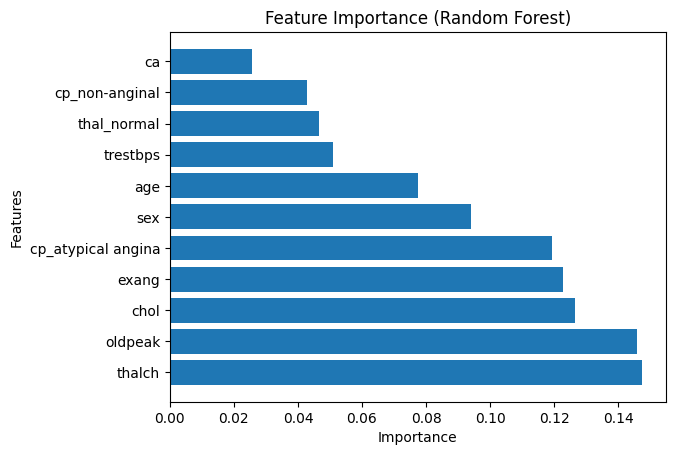

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance (Random Forest)")
plt.show()

In [42]:
X_plot = df[["thalch", "oldpeak"]]
y_plot = df["target"]
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_plot, y_plot, test_size=0.2, random_state=42
)

In [44]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(min_samples_split = 2 , min_samples_leaf  = 5, 
                            n_estimators = 80 , max_samples = 0.75 , random_state= 42 , max_depth = 8 , bootstrap = True, oob_score = True)

rf.fit(X_train, y_train)
ypred_ = rf.predict(X_test)

In [45]:
from sklearn.metrics import confusion_matrix , accuracy_score
cm = confusion_matrix(y_test , ypred_)
print(cm)
print(accuracy_score(ypred_ , y_test))

[[52 23]
 [26 83]]
0.7336956521739131


C:\Users\Acer.DESKTOP-OGQID04\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


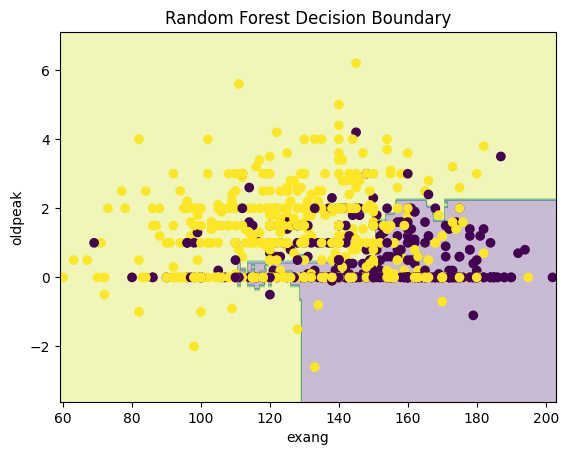

In [49]:
import matplotlib.pyplot as plt

x_min, x_max = X_plot.iloc[:,0].min() - 1, X_plot.iloc[:,0].max() + 1
y_min, y_max = X_plot.iloc[:,1].min() - 1, X_plot.iloc[:,1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),
    np.arange(y_min, y_max, 0.1)
)

Z = rf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(X_plot.iloc[:,0], X_plot.iloc[:,1], c=y_plot)

plt.xlabel("exang")
plt.ylabel("oldpeak")

plt.title("Random Forest Decision Boundary")

plt.show()

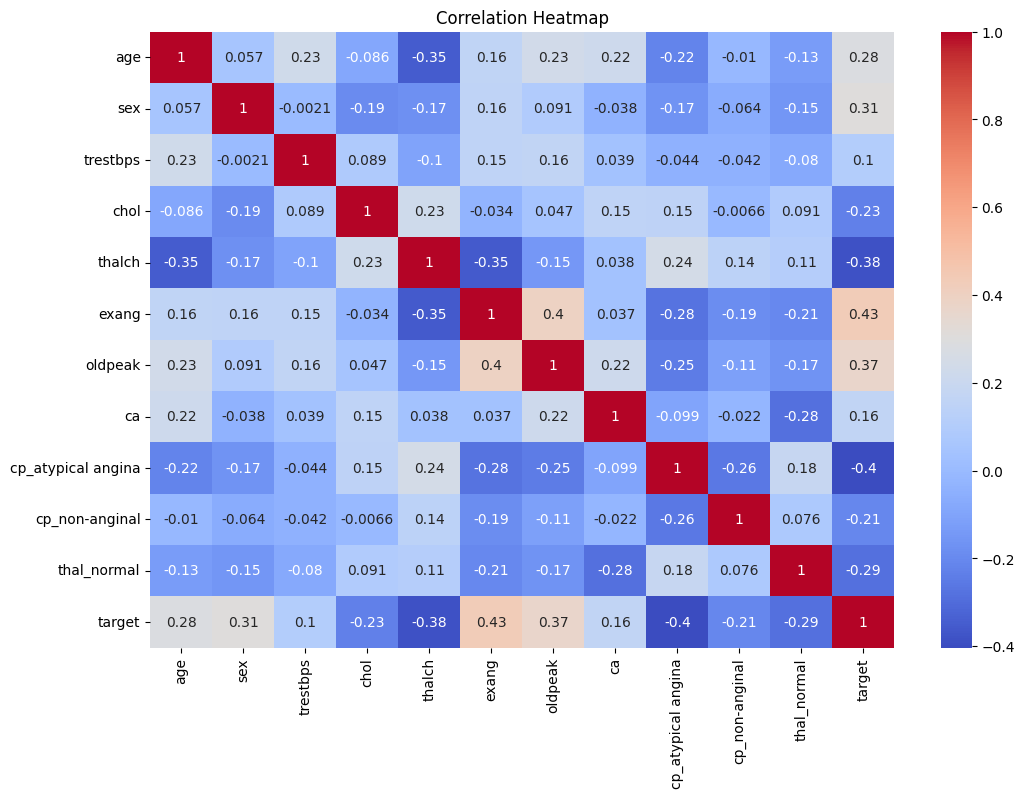

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

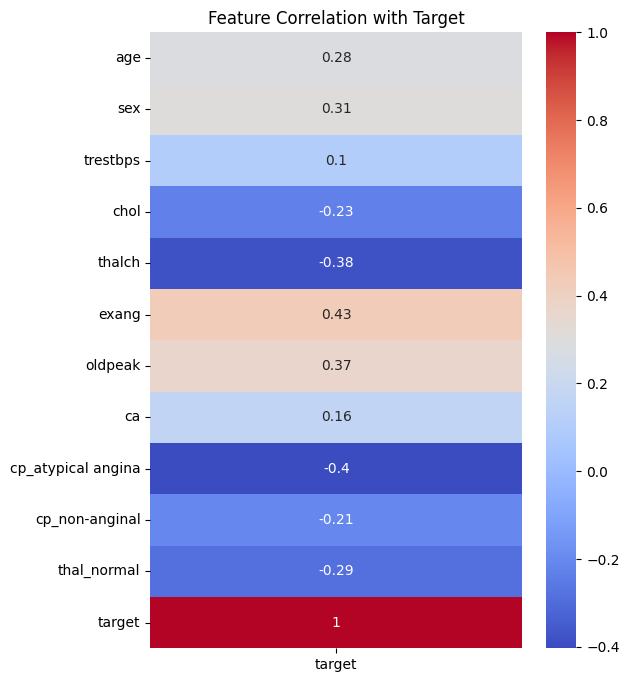

In [51]:
plt.figure(figsize=(6,8))
sns.heatmap(df.corr()[["target"]], annot=True, cmap="coolwarm")

plt.title("Feature Correlation with Target")
plt.show()